# GADDS GFRM File Analysis

Comprehensive analysis workflow for Bruker GADDS GFRM files including:
- Data loading and header inspection
- Detector image to 2θ-γ space conversion
- Integration analysis over specified ranges
- Visualization of results

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib as mpl
from gadds import AreaDetectorImage
import os

plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10
mpl.rcParams['mathtext.default'] = 'regular'

In [2]:
gfrm_file = r"test\20250709_S_MeO_B01_000.gfrm"

if os.path.exists(gfrm_file):
    print(f"Loading file: {gfrm_file}")
else:
    print(f"File not found: {gfrm_file}")
    print("Please update the file path above")

Loading file: test\20250709_S_MeO_B01_000.gfrm


In [3]:
try:
    area_detector = AreaDetectorImage(gfrm_file)
    print("Successfully loaded GFRM file!")
    print(f"Image shape: {area_detector.image.data.shape}")
except Exception as e:
    print(f"Error loading file: {e}")
    raise

  File "c:\Users\danielliu\Documents\git-local\gaddsconverter\gadds.py", line 91, in rowcol_to_angles
    nX, nY = self.image.dim1, self.image.dim2
  File "c:\Users\danielliu\Documents\git-local\gaddsconverter\gadds.py", line 91, in rowcol_to_angles
    nX, nY = self.image.dim1, self.image.dim2
  File "c:\Users\danielliu\Documents\git-local\gaddsconverter\gadds.py", line 91, in rowcol_to_angles
    nX, nY = self.image.dim1, self.image.dim2


Successfully loaded GFRM file!
Image shape: (2048, 2048)


In [4]:
# Display header information
print("=== GFRM File Header Information ===")
if hasattr(area_detector.image, 'header'):
    for key, value in area_detector.image.header.items():
        print(f"{key}: {value}")
else:
    print("No header information available")

print("\n=== Processed Parameters ===")
print(f"Alpha (2θ center): {np.rad2deg(area_detector.alpha):.2f}°")
print(f"Chi angle: {np.rad2deg(area_detector.chi):.2f}°")
print(f"Distance: {area_detector.distance:.2f} cm")
print(f"Detector center (x, y): {area_detector.centerXY}")
print(f"Goniometer stage position (x, y, z, aux): {area_detector.goniometer_pos} mm")
print(f"Pixel density (x, y): {area_detector.densityXY} pixels/cm")
print(f"Scale factor: {area_detector.scale}")
print(f"Offset: {area_detector.offset}")

=== GFRM File Header Information ===
FORMAT: 86
VERSION: 8
HDRBLKS: 15
TYPE: UNWARPED
SITE: Bruker AXS Inc
MODEL: D8
USER: UC Berkeley
SAMPLE: Corundum
SETNAME: 20250709_S_MeO
RUN: 14257
SAMPNUM: 0
TITLE: 20250709_S_MeO
20250709_S_MeO






NCOUNTS: 4655316
NOVERFL: 1453
MINIMUM: 0
MAXIMUM: 1085
NONTIME: 4831105
NLATE: 0
FILENAM: 
CREATED: 07/11/25   14:45:04
CUMULAT: 300.0000000
ELAPSDR: 300.0000000
ELAPSDA: 300.0000000
OSCILLA: 2
NSTEPS: 1
RANGE: 10.0000000
START: -10.0000000
INCREME: 0.0000000
NUMBER: 1
NFRAMES: 2
ANGLES: 20.0000000     5.0000000     0.0000000    90.0000000
NOVER64: 370
NPIXELB: 1
NROWS: 2048
NCOLS: 2048
WORDORD: 0
LONGORD: 0
TARGET: Co
SOURCEK: 35.0000000
SOURCEM: 40.0000000
FILTER: Parallel, Graphite
CELL: 1.0000000     1.0000000     1.0000000    90.0000000    90.0000000
90.0000000
MATRIX: 1.0000000     0.0000000     0.0000000     0.0000000     1.0000000
0.0000000     0.0000000     0.0000000     1.0000000
LOWTEMP: 0
ZOOM: 0.0000000     0.0000000     1.0000000
CENT

In [ ]:
# Plot the original detector image
fig, (ax, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Original image
im1 = ax.imshow(area_detector.image.data, 
                 cmap='viridis',
                 norm=colors.LogNorm(vmin=1, vmax=np.max(area_detector.image.data)),
                 origin='upper')
ax.set_title('Original Detector Image')
ax.set_xlabel('Pixel (X)')
ax.set_ylabel('Pixel (Y)')

# Add center cross
cx, cy = area_detector.centerXY
ax.axhline(y=area_detector.image.shape[0] - cy, color='red', linestyle='--', alpha=0.7, label='Center')
ax.axvline(x=cx, color='red', linestyle='--', alpha=0.7)
ax.legend()

fig.colorbar(im1, ax=ax, label='Intensity (counts)')

# Show statistics
ax2.axis('off')
stats_text = f"""
Image Statistics:
• Shape: {area_detector.image.data.shape}
• Min intensity: {np.min(area_detector.image.data)}
• Max intensity: {np.max(area_detector.image.data)}
• Mean intensity: {np.mean(area_detector.image.data):.1f}
• Total counts: {np.sum(area_detector.image.data)}

Detector Parameters:
• 2θ center: {np.rad2deg(area_detector.alpha):.2f}°
• Distance: {area_detector.distance:.2f} cm
• Center: ({area_detector.centerXY[0]:.1f}, {area_detector.centerXY[1]:.1f})
• Pixel density: ({area_detector.densityXY[0]:.1f}, {area_detector.densityXY[1]:.1f}) px/cm
"""
ax2.text(0.1, 0.9, stats_text, transform=ax2.transAxes, 
         verticalalignment='top', fontfamily='monospace', fontsize=10)

plt.tight_layout()
plt.show()

KeyboardInterrupt: 

In [ ]:
# Convert the image to 2θ-γ space
print("Converting to 2θ-γ space...")
area_detector.convert()
print(f"Converted image shape: {area_detector.data_converted.shape}")
print(f"2θ range: {np.rad2deg(area_detector.limits[0]):.2f}° to {np.rad2deg(area_detector.limits[1]):.2f}°")
print(f"γ range: {np.rad2deg(area_detector.limits[2]):.2f}° to {np.rad2deg(area_detector.limits[3]):.2f}°")

Converting to 2θ-γ space...
Converted image shape: (2048, 2048)
2θ range: 2.46° to 39.97°
γ range: -171.75° to -8.29°
Converted image shape: (2048, 2048)
2θ range: 2.46° to 39.97°
γ range: -171.75° to -8.29°


Adding gridlines for 2θ values: [ 2.  7. 12. 17. 22. 27. 32. 37.]°


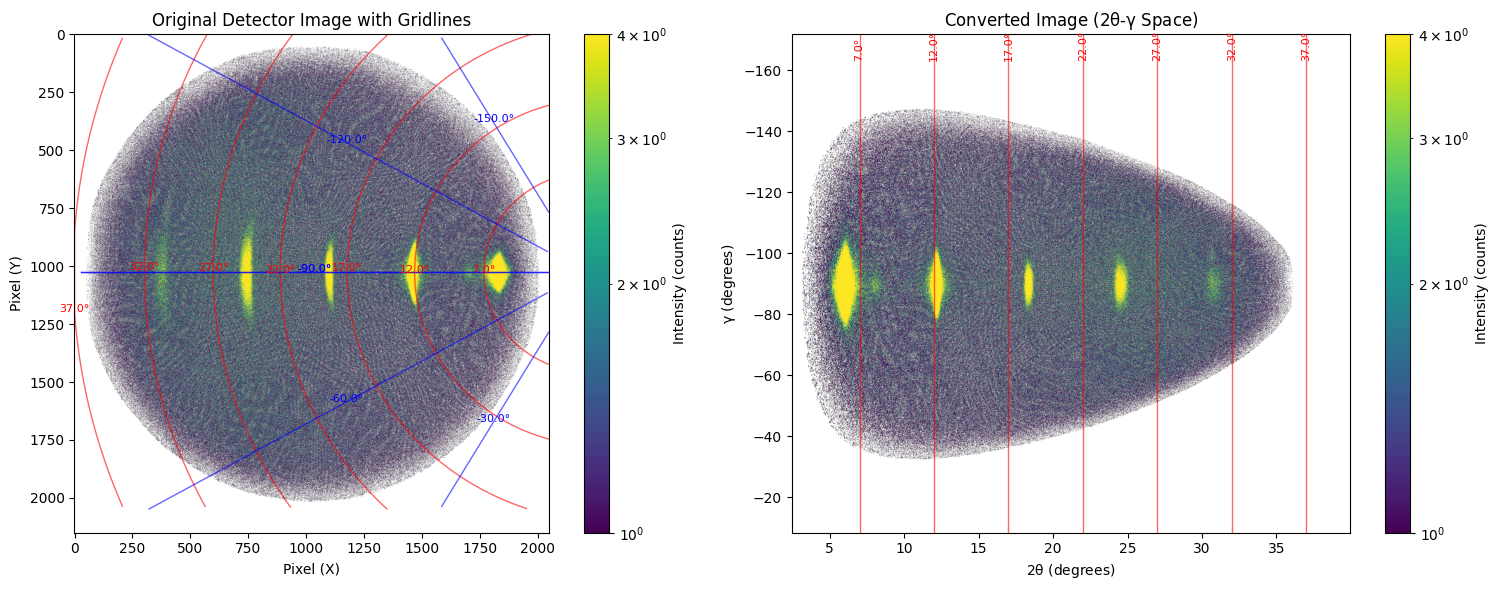

In [ ]:
# Plot both original and converted images side by side
fig, (ax, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Original detector image with gridlines
im1 = ax.imshow(area_detector.image.data, 
                #  cmap=(mpl.cm.viridis).with_extremes(under='black'),
                 cmap='viridis',
                 norm=colors.LogNorm(vmin=1, vmax=np.percentile(area_detector.image.data, 99)),
                 origin='upper')
ax.set_title('Original Detector Image with Gridlines')
ax.set_xlabel('Pixel (X)')
ax.set_ylabel('Pixel (Y)')

theta_min, theta_max, gamma_min, gamma_max = np.rad2deg(area_detector.limits)

# Add gridlines for constant 2θ values
twoth_values = np.arange(*np.round([theta_min, theta_max]), 5)  # degrees
print(f"Adding gridlines for 2θ values: {twoth_values}°")
# twoth_values = [10, 15, 20, 25, 30, 35, 40]  # degrees
for twoth in twoth_values:
    if area_detector.limits[0] <= np.deg2rad(twoth) <= area_detector.limits[1]:
        x_grid, y_grid = area_detector.gridline(twoth, axis='twoth', delta_deg=0.5)
        if len(x_grid) > 0:
            ax.plot(x_grid, y_grid, 'r-', alpha=0.6, linewidth=1)
            # Add label
            if len(x_grid) > 10:
                mid_idx = len(x_grid) // 2
                ax.text(x_grid[mid_idx], y_grid[mid_idx], f'{twoth}°', 
                        color='red', fontsize=8, ha='center')

# Add gridlines for constant γ values
gamma_values = [*np.arange(*np.round([-90, gamma_min]), -30), *np.arange(*np.round([-90, gamma_max]), 30)]  # degrees
for gamma in gamma_values:
    if area_detector.limits[2] <= np.deg2rad(gamma) <= area_detector.limits[3]:
        x_grid, y_grid = area_detector.gridline(gamma, axis='gamma', delta_deg=0.5)
        if len(x_grid) > 0:
            ax.plot(x_grid, y_grid, 'b-', alpha=0.6, linewidth=1)
            # Add label
            if len(x_grid) > 10:
                mid_idx = len(x_grid) // 2
                ax.text(x_grid[mid_idx], y_grid[mid_idx], f'{gamma}°', 
                        color='blue', fontsize=8, ha='center')

fig.colorbar(im1, ax=ax, label='Intensity (counts)')

# Converted image in 2θ-γ space

# Calculate pixel spacing and extent with half-pixel offsets
# The dx/2 and dy/2 offsets ensure pixel centers align with coordinate values
# rather than pixel edges, preventing data misalignment in imshow()
dx = area_detector.indexes[1][1] - area_detector.indexes[1][0]
dy = area_detector.indexes[0][1] - area_detector.indexes[0][0]
extent = (
    area_detector.indexes[1][0] - dx/2, area_detector.indexes[1][-1] + dx/2,
    area_detector.indexes[0][-1] - dy/2, area_detector.indexes[0][0] + dy/2
)

im2 = ax2.imshow(area_detector.data_converted,
                 cmap='viridis',
                 norm=colors.LogNorm(vmin=1, vmax=np.percentile(area_detector.data_converted, 99)),
                 origin='upper',
                 extent=extent,
                 aspect='auto')
ax2.set_title('Converted Image (2$\\theta$-$\\gamma$ Space)')
ax2.set_xlabel('2$\\theta$ (degrees)')
ax2.set_ylabel('$\\gamma$ (degrees)')

# Add grid for constant 2θ and γ
for twoth in twoth_values:
    if extent[0] <= twoth <= extent[1]:
        ax2.axvline(x=twoth, color='red', alpha=0.6, linewidth=1)
        ax2.text(twoth, extent[3] - (extent[3] - extent[2]) * 0.05, f'{twoth}°', 
                color='red', fontsize=8, ha='center', rotation=90)

for gamma in gamma_values:
    if extent[2] <= gamma <= extent[3]:
        ax2.axhline(y=gamma, color='blue', alpha=0.6, linewidth=1)
        ax2.text(extent[0] + (extent[1] - extent[0]) * 0.02, gamma, f'{gamma}°', 
                color='blue', fontsize=8, va='center')

fig.colorbar(im2, ax=ax2, label='Intensity (counts)')

plt.tight_layout()
plt.show()

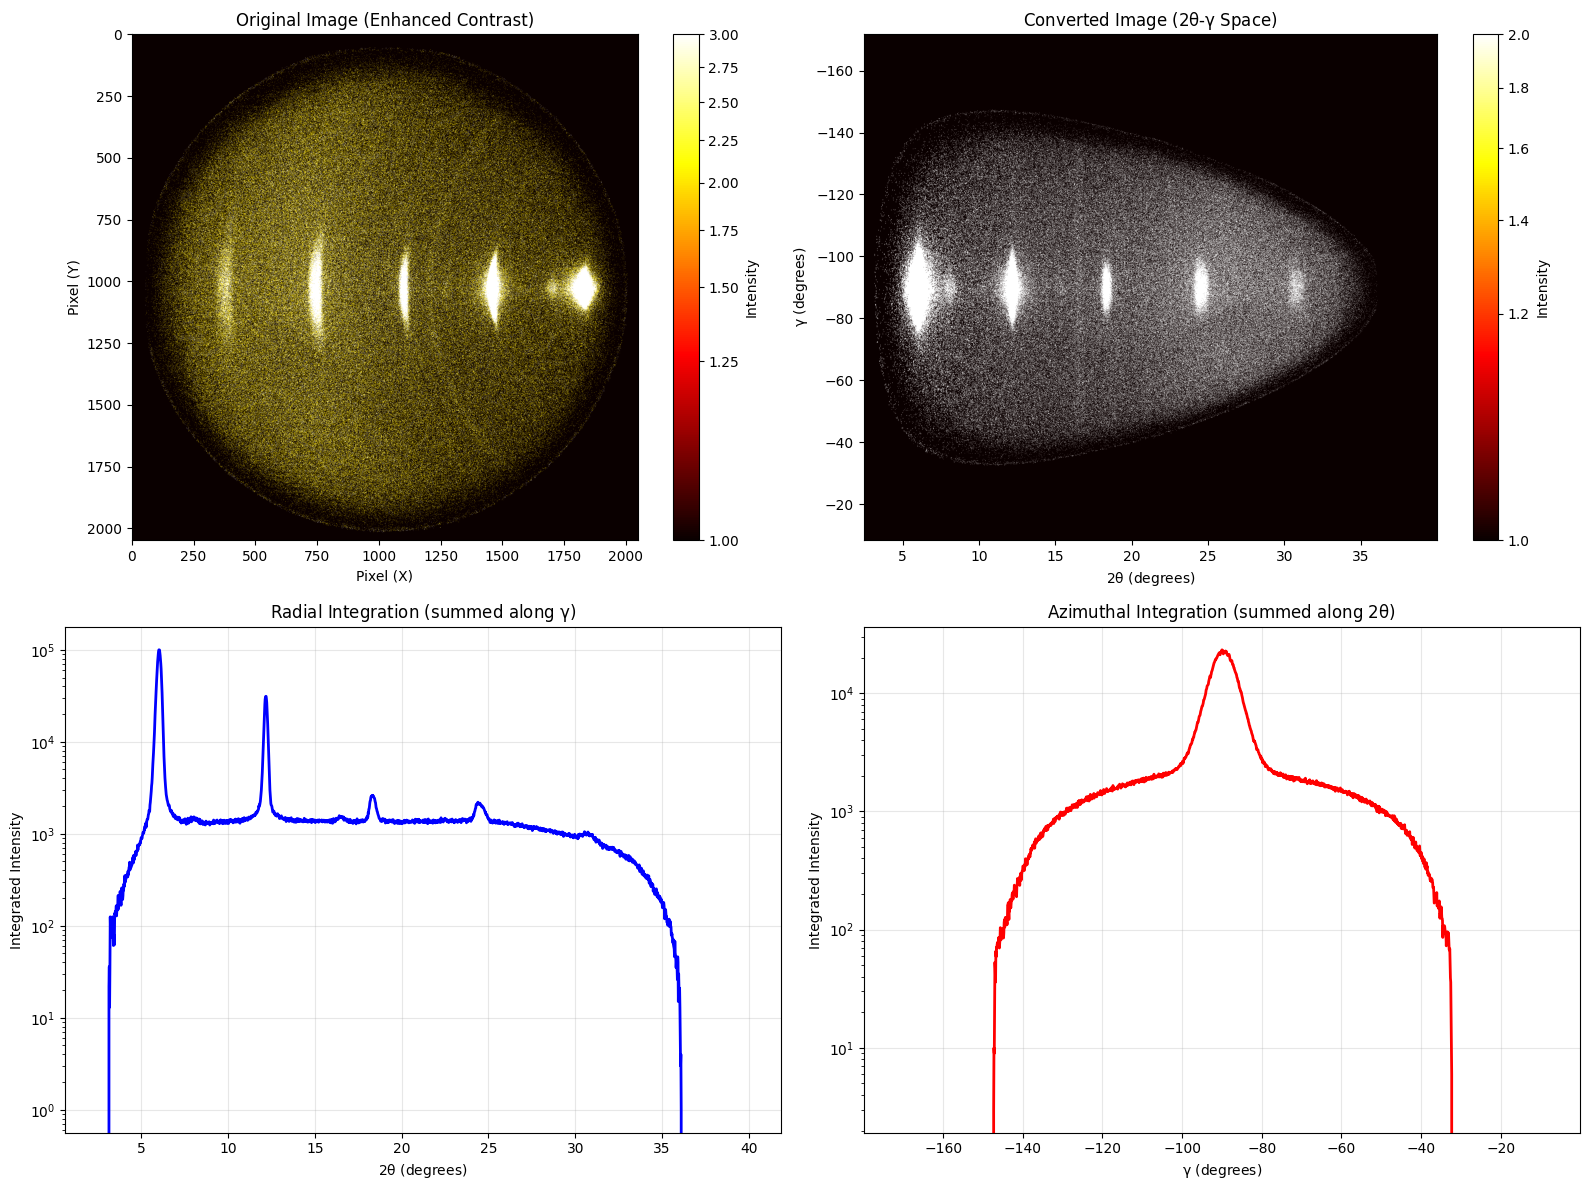

In [ ]:
# Create a more detailed analysis plot
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Original image with enhanced contrast
im1 = axes[0,0].imshow(area_detector.image.data, 
                       cmap='hot',
                       norm=colors.PowerNorm(gamma=0.5, vmin=1, vmax=np.percentile(area_detector.image.data, 95)),
                       origin='upper')
axes[0,0].set_title('Original Image (Enhanced Contrast)')
axes[0,0].set_xlabel('Pixel (X)')
axes[0,0].set_ylabel('Pixel (Y)')
fig.colorbar(im1, ax=axes[0,0], label='Intensity')

# 2. Converted image
im2 = axes[0,1].imshow(area_detector.data_converted,
                       cmap='hot',
                       norm=colors.PowerNorm(gamma=0.5, vmin=1, vmax=np.percentile(area_detector.data_converted, 95)),
                       origin='upper',
                       extent=extent,
                       aspect='auto')
axes[0,1].set_title('Converted Image (2$\\theta$-$\\gamma$ Space)')
axes[0,1].set_xlabel('2$\\theta$ (degrees)')
axes[0,1].set_ylabel('$\\gamma$ (degrees)')
fig.colorbar(im2, ax=axes[0,1], label='Intensity')

# 3. Radial integration (sum along γ)
radial_profile = np.sum(area_detector.data_converted, axis=0)
axes[1,0].plot(area_detector.indexes[1], radial_profile, 'b-', linewidth=2)
axes[1,0].set_title('Radial Integration (summed along $\\gamma$)')
axes[1,0].set_xlabel('2$\\theta$ (degrees)')
axes[1,0].set_ylabel('Integrated Intensity')
axes[1,0].grid(True, alpha=0.3)
axes[1,0].set_yscale('log')

# 4. Azimuthal integration (sum along 2θ)
azimuthal_profile = np.sum(area_detector.data_converted, axis=1)
axes[1,1].plot(area_detector.indexes[0], azimuthal_profile, 'r-', linewidth=2)
axes[1,1].set_title('Azimuthal Integration (summed along 2$\\theta$)')
axes[1,1].set_xlabel('$\\gamma$ (degrees)')
axes[1,1].set_ylabel('Integrated Intensity')
axes[1,1].grid(True, alpha=0.3)
axes[1,1].set_yscale('log')

plt.tight_layout()
plt.show()

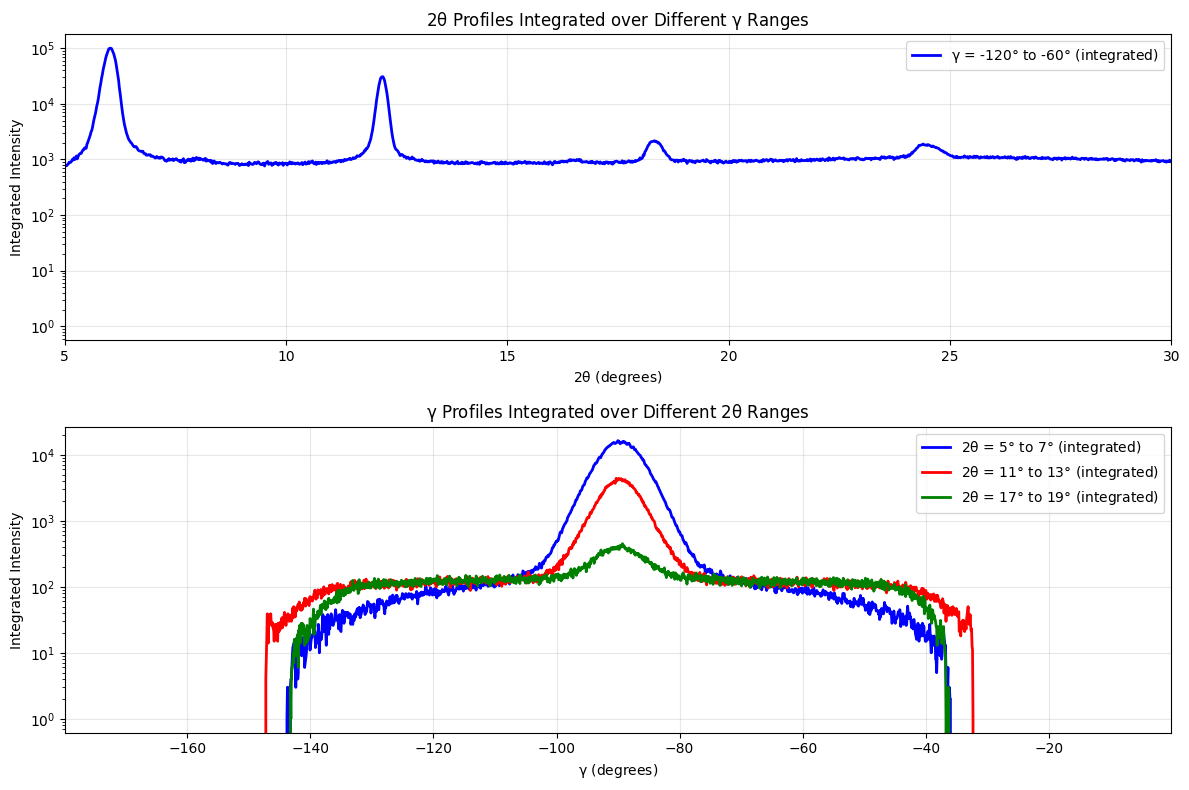

In [ ]:
# Extract and display specific 2θ cuts
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Extract data by integrating over γ ranges (each tuple defines a range to integrate)
gamma_ranges = [(-120, -60)]  # degrees - ranges to integrate over
colors_list = ['blue', 'red', 'green']

for i, (gamma_min, gamma_max) in enumerate(gamma_ranges):
    # Find γ indices corresponding to the range
    gamma_mask = (area_detector.indexes[0] >= gamma_min) & (area_detector.indexes[0] <= gamma_max)
    gamma_indices = np.where(gamma_mask)[0]
    
    if len(gamma_indices) > 0:
        # Integrate (sum) over the γ range
        intensity_slice = np.sum(area_detector.data_converted[gamma_indices, :], axis=0)
        
        axes[0].plot(area_detector.indexes[1], intensity_slice, 
                     color=colors_list[i], linewidth=2, 
                     label=f'$\\gamma$ = {gamma_min}° to {gamma_max}° (integrated)')

axes[0].set_title('2$\\theta$ Profiles Integrated over Different $\\gamma$ Ranges')
axes[0].set_xlabel('2$\\theta$ (degrees)')
axes[0].set_ylabel('Integrated Intensity')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_yscale('log')
axes[0].set_xlim(5, 30)
axes[0].autoscale(axis='y')

# Extract data by integrating over 2θ ranges (each tuple defines a range to integrate)
twoth_ranges = [(5, 7), (11, 13), (17, 19)]  # degrees - ranges to integrate over

for i, (twoth_min, twoth_max) in enumerate(twoth_ranges):
    # Find 2θ indices corresponding to the range
    twoth_mask = (area_detector.indexes[1] >= twoth_min) & (area_detector.indexes[1] <= twoth_max)
    twoth_indices = np.where(twoth_mask)[0]
    
    if len(twoth_indices) > 0:
        # Integrate (sum) over the 2θ range
        intensity_slice = np.sum(area_detector.data_converted[:, twoth_indices], axis=1)
        
        axes[1].plot(area_detector.indexes[0], intensity_slice, 
                     color=colors_list[i], linewidth=2, 
                     label=f'2$\\theta$ = {twoth_min}° to {twoth_max}° (integrated)')

axes[1].set_title('$\\gamma$ Profiles Integrated over Different 2$\\theta$ Ranges')
axes[1].set_xlabel('$\\gamma$ (degrees)')
axes[1].set_ylabel('Integrated Intensity')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()

In [ ]:
%load_ext autoreload
%autoreload 2

Info: 1281901 grid points have overlapping detector pixels (max 6 pixels per grid point)


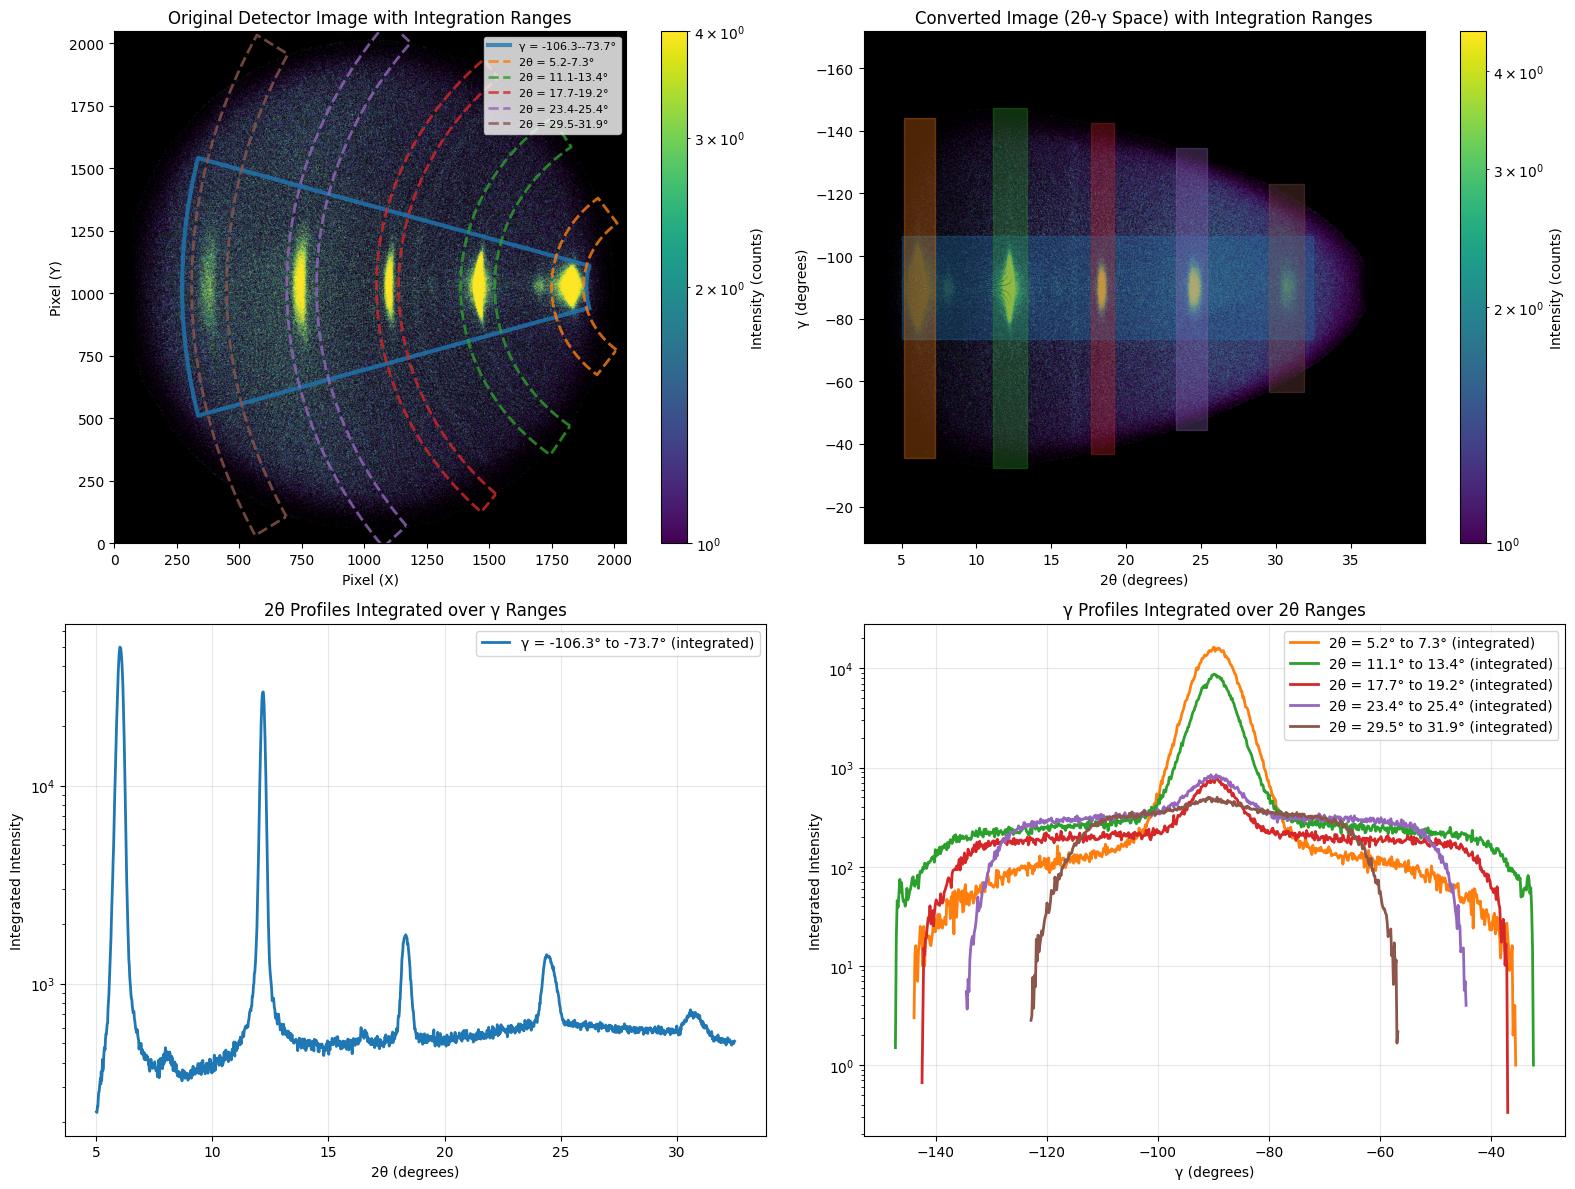

In [2]:
from gadds import AreaDetectorImage
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors

from package.analysis_utils import correct_baseline, find_peaks_and_widths

# Load and convert data
gfrm_file = r"test\20250709_S_MeO_B01_000.gfrm"
area_detector = AreaDetectorImage(gfrm_file)
area_detector.convert()

# Calculate extent for converted image
dx = area_detector.indexes[1][1] - area_detector.indexes[1][0]
dy = area_detector.indexes[0][1] - area_detector.indexes[0][0]
extent = (
    area_detector.indexes[1][0] - dx/2, area_detector.indexes[1][-1] + dx/2,
    area_detector.indexes[0][-1] - dy/2, area_detector.indexes[0][0] + dy/2
)


# Create comprehensive visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

axes[0,0].set_facecolor('black')
axes[0,1].set_facecolor('black')

# Plot 1: Original detector image with integration masks
im1 = axes[0,0].imshow(
    area_detector.image.data, 
    cmap='viridis',
    norm=colors.LogNorm(vmin=1, vmax=np.percentile(area_detector.image.data, 99)),
    origin='upper'
)
axes[0,0].set_title('Original Detector Image with Integration Ranges')
axes[0,0].set_xlabel('Pixel (X)')
axes[0,0].set_ylabel('Pixel (Y)')

# Add gamma integration masks to original detector

# intensity, mask = area_detector.integrate(twotheta_range=twoth_range, gamma_range=gamma_range)
intensity, (twoth_range, gamma_range), mask = area_detector.integrate_2theta()
line, = axes[0,0].plot(*mask, linewidth=3, alpha=0.8, 
                        label=f'γ = {gamma_range[0]:.1f}-{gamma_range[1]:.1f}°')

# Add corresponding rectangle to converted image
axes[0,1].add_patch(plt.Rectangle(
    (twoth_range[0], gamma_range[0]), 
    twoth_range[1]-twoth_range[0], 
    gamma_range[1]-gamma_range[0], 
    alpha=0.3, color=line.get_color(), transform=axes[0,1].transData
))

# Plot integrated profile
axes[1,0].plot(*intensity, linewidth=2, color=line.get_color(),
                label=f'γ = {gamma_range[0]:.1f}° to {gamma_range[1]:.1f}° (integrated)')


(twoth_values, intensity), *_ = area_detector.integrate_2theta()
corrected_intensity, _ = correct_baseline(twoth_values, intensity, offset=100)
peaks, peaks_prop = find_peaks_and_widths(twoth_values, corrected_intensity, width_at_height=1, wlen=2.5)
twoth_ranges = [
    (prop['left_ip'], prop['right_ip']) for prop in peaks_prop
]

# Add 2θ integration masks to original detector
for i, twoth_range in enumerate(twoth_ranges):
    gamma_range = (-115, -65)
    intensity, (twoth_range, gamma_range), mask = area_detector.integrate_gamma(twotheta_range=twoth_range)
    line, = axes[0,0].plot(*mask, linewidth=2, alpha=0.8, 
                          linestyle='--', label=f'2θ = {twoth_range[0]:.1f}-{twoth_range[1]:.1f}°')
    
    # Add corresponding rectangle to converted image
    axes[0,1].add_patch(plt.Rectangle(
        (twoth_range[0], gamma_range[0]), 
        twoth_range[1]-twoth_range[0], 
        gamma_range[1]-gamma_range[0], 
        alpha=0.3, color=line.get_color(), transform=axes[0,1].transData
    ))
    
    # Plot integrated profile
    axes[1,1].plot(*intensity, color=line.get_color(), linewidth=2, 
                   label=f'2θ = {twoth_range[0]:.1f}° to {twoth_range[1]:.1f}° (integrated)')

axes[0,0].legend(loc='upper right', fontsize=8)
axes[0,0].set_xlim(0, area_detector.image.data.shape[1])
axes[0,0].set_ylim(0, area_detector.image.data.shape[0])
plt.colorbar(im1, ax=axes[0,0], label='Intensity (counts)')

# Plot 2: Converted image in 2θ-γ space
im2 = axes[0,1].imshow(
    area_detector.data_converted,
    cmap='viridis',
    norm=colors.LogNorm(vmin=1, vmax=np.percentile(area_detector.data_converted.compressed(), 99)),
    origin='upper', extent=extent, aspect='auto'
)
axes[0,1].set_title('Converted Image (2θ-γ Space) with Integration Ranges')
axes[0,1].set_xlabel('2θ (degrees)')
axes[0,1].set_ylabel('γ (degrees)')
plt.colorbar(im2, ax=axes[0,1], label='Intensity (counts)')

# Plot 3: 2θ profiles
axes[1,0].set_title('2θ Profiles Integrated over γ Ranges')
axes[1,0].set_xlabel('2θ (degrees)')
axes[1,0].set_ylabel('Integrated Intensity')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)
axes[1,0].set_yscale('log')

# Plot 4: γ profiles
axes[1,1].set_title('γ Profiles Integrated over 2θ Ranges')
axes[1,1].set_xlabel('γ (degrees)')
axes[1,1].set_ylabel('Integrated Intensity')
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)
axes[1,1].set_yscale('log')

plt.tight_layout()
plt.show()


Info: 1281901 grid points have overlapping detector pixels (max 6 pixels per grid point)


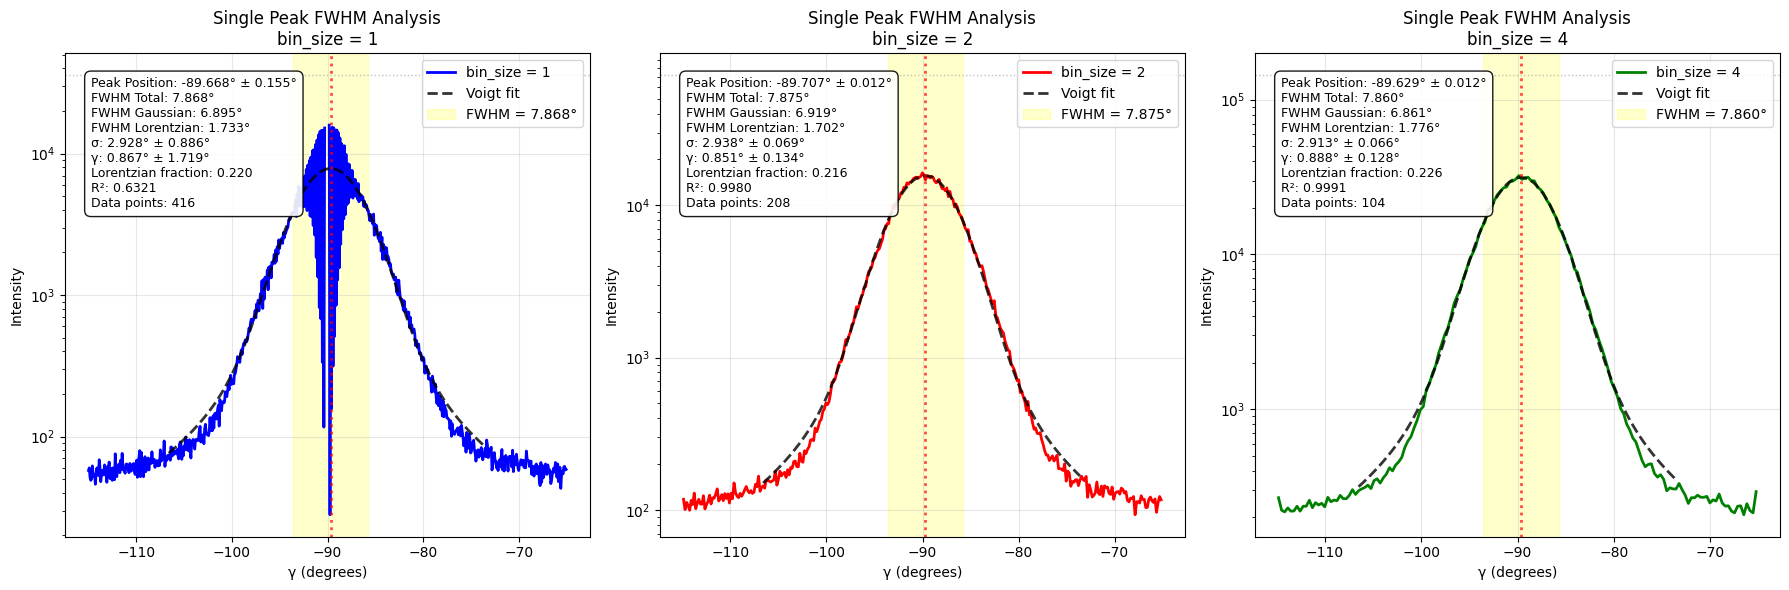

=== Single Peak Voigt Profile FWHM Analysis Summary ===
Bin  Position   Pos_Err  FWHM     FWHM_G   FWHM_L   σ        σ_Err   γ        γ_Err   L-frac  R²      Points
---------------------------------------------------------------------------------------------------------
1    -89.6681   0.1546   7.8682   6.8945   1.7333   2.9276   0.8857  0.8666   1.7186  0.220   0.6321  416   
2    -89.7074   0.0120   7.8745   6.9192   1.7025   2.9381   0.0686  0.8512   0.1335  0.216   0.9980  208   
4    -89.6288   0.0115   7.8601   6.8609   1.7762   2.9134   0.0660  0.8881   0.1276  0.226   0.9991  104   


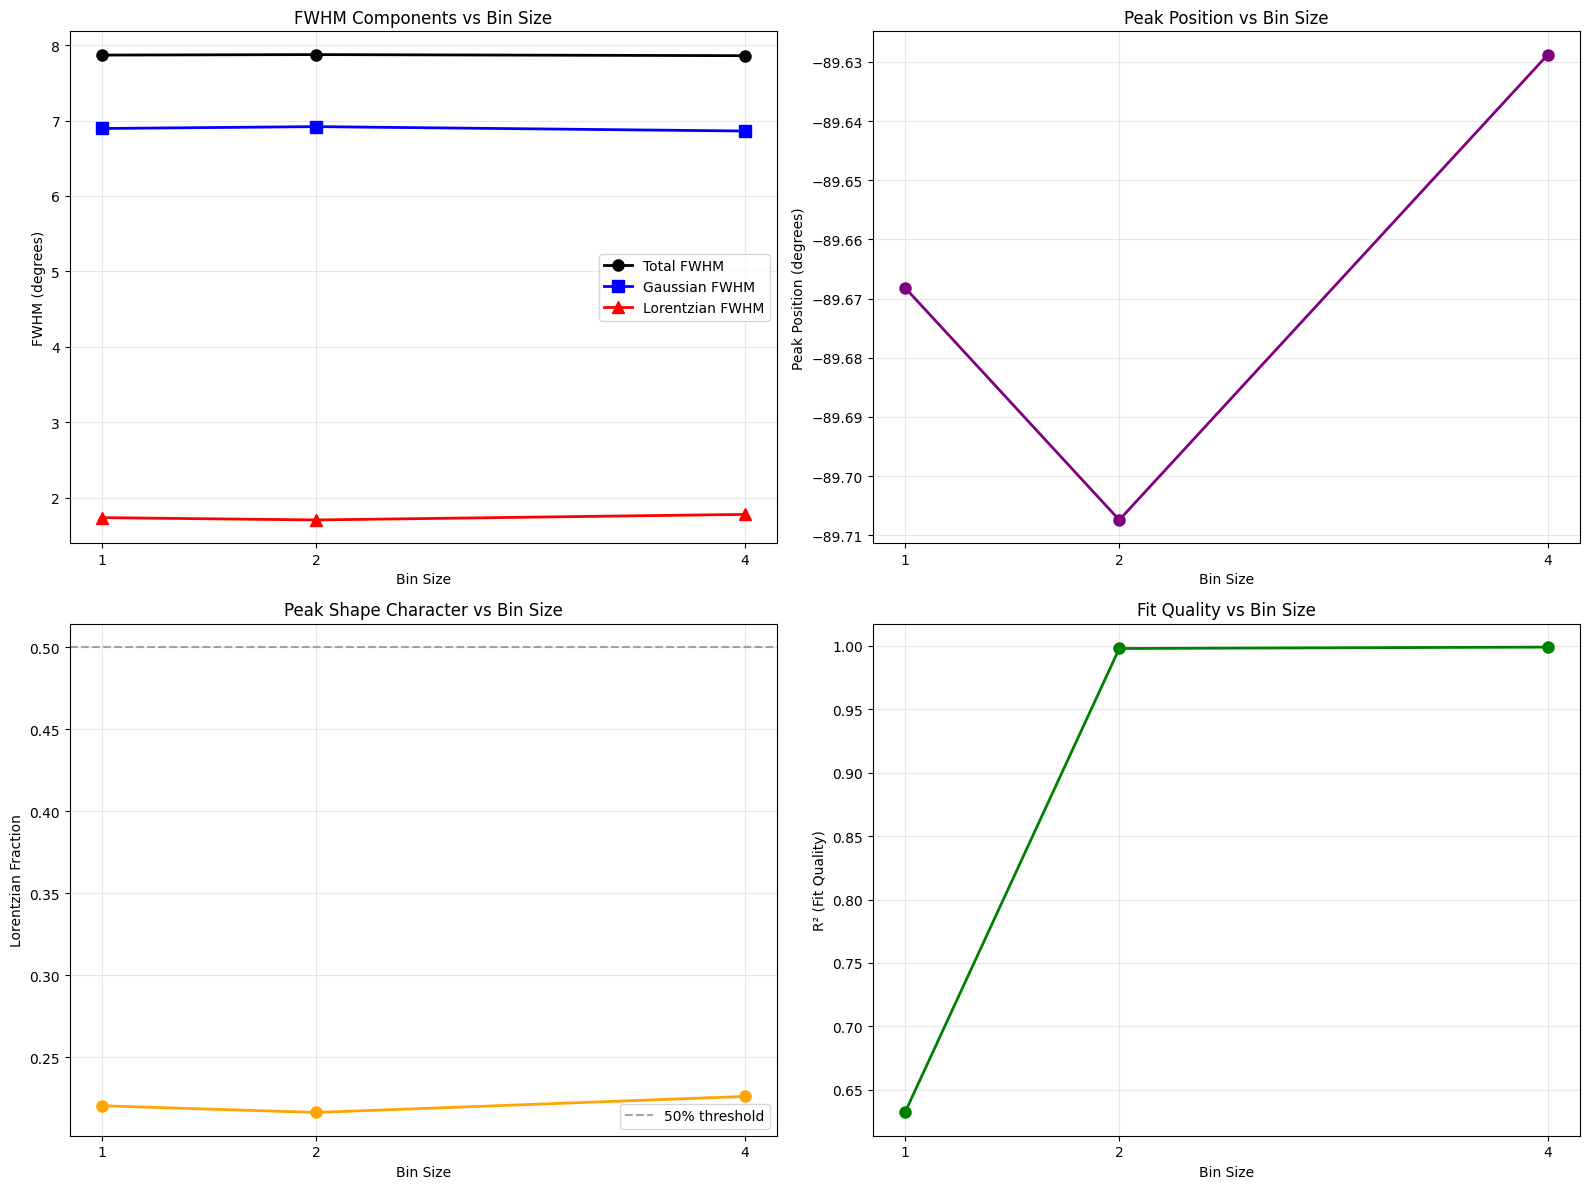


=== Statistical Summary ===
FWHM Analysis Summary (n=3 successful fits):
  Total FWHM range: 7.8601° to 7.8745°
  Mean Total FWHM: 7.8676° ± 0.0059°
  Gaussian component: 6.8915° ± 0.0239°
  Lorentzian component: 1.7373° ± 0.0302°
  Peak position: -89.6681° ± 0.0321°
  Mean Lorentzian fraction: 0.221 ± 0.004
  Mean fit quality (R²): 0.8764 ± 0.1727

Bin Size Effect Analysis:
  FWHM change from bin_size 1 to 4: -0.10%
  Peak position stability: ±0.0394°
  Best fit quality at bin_size = 4 (R² = 0.9991)

Interpretation:
• Lorentzian fraction < 0.5: Predominantly Gaussian broadening (instrumental/size effects)
• Lorentzian fraction > 0.5: Predominantly Lorentzian broadening (strain/disorder effects)
• Higher R² values indicate better fit quality
• Bin size affects both resolution and noise - choose based on balance of accuracy and precision


In [ ]:
from gadds import AreaDetectorImage
import matplotlib.pyplot as plt
import numpy as np
from scipy import signal
from scipy.optimize import curve_fit
from scipy.special import wofz

def voigt(x, amplitude, center, sigma, gamma, baseline):
    """
    Voigt profile function
    x: independent variable
    amplitude: peak amplitude
    center: peak center
    sigma: Gaussian width parameter
    gamma: Lorentzian width parameter (HWHM)
    baseline: constant baseline
    """
    z = ((x - center) + 1j*gamma) / (sigma * np.sqrt(2))
    return amplitude * np.real(wofz(z)) / (sigma * np.sqrt(2*np.pi)) + baseline

def voigt_fwhm(sigma, gamma):
    """
    Calculate FWHM for Voigt profile
    Approximation from Olivero & Longbothum (1977)
    """
    fwhm_gauss = 2.355 * sigma  # 2*sqrt(2*ln(2)) * sigma
    fwhm_lorentz = 2 * gamma
    
    # Approximation for Voigt FWHM
    fwhm_voigt = 0.5346 * fwhm_lorentz + np.sqrt(0.2166 * fwhm_lorentz**2 + fwhm_gauss**2)
    return fwhm_voigt

def find_single_peak_fwhm(x, y):
    """
    Calculate FWHM for a single peak using Voigt profile fitting
    """
    try:
        # Find the peak position
        peak_idx = np.argmax(y)
        
        # Use a wider fitting window for better accuracy
        window_size = len(x) // 3  # Use about 1/3 of the data around peak
        start_idx = max(0, peak_idx - window_size)
        end_idx = min(len(x), peak_idx + window_size)
        
        x_fit = x[start_idx:end_idx]
        y_fit = y[start_idx:end_idx]
        
        # Initial parameter estimates
        amplitude_guess = y[peak_idx] - np.min(y_fit)
        center_guess = x[peak_idx]
        sigma_guess = 0.5  # Initial Gaussian width
        gamma_guess = 0.3  # Initial Lorentzian HWHM
        baseline_guess = np.min(y_fit)
        
        # Fit Voigt profile
        popt, pcov = curve_fit(
            voigt, x_fit, y_fit,
            p0=[amplitude_guess, center_guess, sigma_guess, gamma_guess, baseline_guess],
            bounds=([0, x_fit[0], 0.01, 0.01, 0], 
                   [np.inf, x_fit[-1], 10, 10, np.inf]),
            maxfev=10000
        )
        
        amplitude, center, sigma, gamma, baseline = popt
        fwhm = voigt_fwhm(sigma, gamma)
        
        # Calculate individual FWHM components
        fwhm_gauss = 2.355 * sigma
        fwhm_lorentz = 2 * gamma
        
        # Calculate R-squared
        y_pred = voigt(x_fit, *popt)
        ss_res = np.sum((y_fit - y_pred) ** 2)
        ss_tot = np.sum((y_fit - np.mean(y_fit)) ** 2)
        r_squared = 1 - (ss_res / ss_tot) if ss_tot > 0 else 0
        
        # Calculate parameter uncertainties
        param_errors = np.sqrt(np.diag(pcov))
        
        result = {
            'peak_position': center,
            'peak_position_error': param_errors[1],
            'fwhm': fwhm,
            'fwhm_gaussian': fwhm_gauss,
            'fwhm_lorentzian': fwhm_lorentz,
            'amplitude': amplitude,
            'sigma': sigma,
            'sigma_error': param_errors[2],
            'gamma': gamma,
            'gamma_error': param_errors[3],
            'baseline': baseline,
            'r_squared': r_squared,
            'fit_params': popt,
            'param_errors': param_errors,
            'fit_x': x_fit,
            'fit_y': y_pred,
            'lorentz_fraction': fwhm_lorentz / fwhm,
            'data_points': len(x_fit)
        }
        
        return result
        
    except Exception as e:
        print(f"Failed to fit peak: {e}")
        return None

# Load and convert data
gfrm_file = r"test\20250709_S_MeO_B01_000.gfrm"
area_detector = AreaDetectorImage(gfrm_file)
area_detector.convert()

# Test bin sizes 1-3 as requested
bin_sizes = [1, 2, 4]
colors = ['blue', 'red', 'green']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Store results for comparison
fwhm_results = {}

for i, bin_size in enumerate(bin_sizes):
    (gamma_values, intensity), _ = area_detector.integrate(
        twotheta_range=(5, 7), 
        gamma_range=(-115, -65), 
        mode='gamma',
        bin_size=bin_size
    )
    
    # Plot the data
    (ax) = axes[i]
    (ax).plot(gamma_values, intensity, color=colors[i], linewidth=2, 
            label=f'bin_size = {bin_size}')
    
    # Find and fit the single peak using Voigt profile
    peak_result = find_single_peak_fwhm(gamma_values, intensity)
    
    # Store results
    fwhm_results[bin_size] = peak_result
    
    if peak_result:
        # Plot fitted peak
        (ax).plot(peak_result['fit_x'], peak_result['fit_y'], 'k--', alpha=0.8, linewidth=2,
                label='Voigt fit')
        
        # Mark peak position and FWHM
        peak_pos = peak_result['peak_position']
        fwhm = peak_result['fwhm']
        amplitude = peak_result['amplitude']
        baseline = peak_result['baseline']
        
        # Mark peak center
        (ax).axvline(peak_pos, color='red', linestyle=':', alpha=0.7, linewidth=2)
        
        # Mark FWHM
        half_max = baseline + amplitude / 2
        (ax).axhline(half_max, color='gray', linestyle=':', alpha=0.5, linewidth=1)
        (ax).axvspan(peak_pos - fwhm/2, peak_pos + fwhm/2, 
                   alpha=0.2, color='yellow', label=f'FWHM = {fwhm:.3f}°')
        
        # Add detailed annotation
        (ax).text(0.05, 0.95, 
                f'Peak Position: {peak_pos:.3f}° ± {peak_result["peak_position_error"]:.3f}°\n'
                f'FWHM Total: {fwhm:.3f}°\n'
                f'FWHM Gaussian: {peak_result["fwhm_gaussian"]:.3f}°\n'
                f'FWHM Lorentzian: {peak_result["fwhm_lorentzian"]:.3f}°\n'
                f'σ: {peak_result["sigma"]:.3f}° ± {peak_result["sigma_error"]:.3f}°\n'
                f'γ: {peak_result["gamma"]:.3f}° ± {peak_result["gamma_error"]:.3f}°\n'
                f'Lorentzian fraction: {peak_result["lorentz_fraction"]:.3f}\n'
                f'R²: {peak_result["r_squared"]:.4f}\n'
                f'Data points: {peak_result["data_points"]}',
                transform=(ax).transAxes, verticalalignment='top', fontsize=9,
                bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.9))
    
    (ax).set_xlabel('γ (degrees)')
    (ax).set_ylabel('Intensity')
    (ax).set_title(f'Single Peak FWHM Analysis\nbin_size = {bin_size}')
    (ax).set_yscale('log')
    (ax).grid(True, alpha=0.3)
    (ax).legend(loc='upper right')

plt.tight_layout()
plt.show()

# Summary table
print("=== Single Peak Voigt Profile FWHM Analysis Summary ===")
print(f"{'Bin':<4} {'Position':<10} {'Pos_Err':<8} {'FWHM':<8} {'FWHM_G':<8} {'FWHM_L':<8} {'σ':<8} {'σ_Err':<7} {'γ':<8} {'γ_Err':<7} {'L-frac':<7} {'R²':<7} {'Points':<6}")
print("-" * 105)

valid_results = []
for bin_size in bin_sizes:
    result = fwhm_results[bin_size]
    if result:
        print(f"{bin_size:<4} {result['peak_position']:<10.4f} {result['peak_position_error']:<8.4f} "
              f"{result['fwhm']:<8.4f} {result['fwhm_gaussian']:<8.4f} "
              f"{result['fwhm_lorentzian']:<8.4f} {result['sigma']:<8.4f} {result['sigma_error']:<7.4f} "
              f"{result['gamma']:<8.4f} {result['gamma_error']:<7.4f} {result['lorentz_fraction']:<7.3f} "
              f"{result['r_squared']:<7.4f} {result['data_points']:<6}")
        valid_results.append((bin_size, result))
    else:
        print(f"{bin_size:<4} {'Fit failed'}")

# Create comparison plots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

if valid_results:
    bin_sizes_valid = [br[0] for br in valid_results]
    results_valid = [br[1] for br in valid_results]
    
    # Extract data for plotting
    fwhm_total = [r['fwhm'] for r in results_valid]
    fwhm_gauss = [r['fwhm_gaussian'] for r in results_valid]
    fwhm_lorentz = [r['fwhm_lorentzian'] for r in results_valid]
    positions = [r['peak_position'] for r in results_valid]
    lorentz_fractions = [r['lorentz_fraction'] for r in results_valid]
    r_squared = [r['r_squared'] for r in results_valid]
    
    # Plot 1: FWHM components vs bin_size
    axes[0,0].plot(bin_sizes_valid, fwhm_total, 'o-', color='black', linewidth=2, markersize=8, label='Total FWHM')
    axes[0,0].plot(bin_sizes_valid, fwhm_gauss, 's-', color='blue', linewidth=2, markersize=8, label='Gaussian FWHM')
    axes[0,0].plot(bin_sizes_valid, fwhm_lorentz, '^-', color='red', linewidth=2, markersize=8, label='Lorentzian FWHM')
    axes[0,0].set_xlabel('Bin Size')
    axes[0,0].set_ylabel('FWHM (degrees)')
    axes[0,0].set_title('FWHM Components vs Bin Size')
    axes[0,0].grid(True, alpha=0.3)
    axes[0,0].legend()
    axes[0,0].set_xticks(bin_sizes_valid)
    
    # Plot 2: Peak position vs bin_size
    axes[0,1].plot(bin_sizes_valid, positions, 'o-', color='purple', linewidth=2, markersize=8)
    axes[0,1].set_xlabel('Bin Size')
    axes[0,1].set_ylabel('Peak Position (degrees)')
    axes[0,1].set_title('Peak Position vs Bin Size')
    axes[0,1].grid(True, alpha=0.3)
    axes[0,1].set_xticks(bin_sizes_valid)
    
    # Plot 3: Lorentzian fraction vs bin_size
    axes[1,0].plot(bin_sizes_valid, lorentz_fractions, 'o-', color='orange', linewidth=2, markersize=8)
    axes[1,0].axhline(y=0.5, color='gray', linestyle='--', alpha=0.7, label='50% threshold')
    axes[1,0].set_xlabel('Bin Size')
    axes[1,0].set_ylabel('Lorentzian Fraction')
    axes[1,0].set_title('Peak Shape Character vs Bin Size')
    axes[1,0].grid(True, alpha=0.3)
    axes[1,0].legend()
    axes[1,0].set_xticks(bin_sizes_valid)
    
    # Plot 4: Fit quality (R²) vs bin_size
    axes[1,1].plot(bin_sizes_valid, r_squared, 'o-', color='green', linewidth=2, markersize=8)
    axes[1,1].set_xlabel('Bin Size')
    axes[1,1].set_ylabel('R² (Fit Quality)')
    axes[1,1].set_title('Fit Quality vs Bin Size')
    axes[1,1].grid(True, alpha=0.3)
    axes[1,1].set_xticks(bin_sizes_valid)

plt.tight_layout()
plt.show()

# Statistical summary
print("\n=== Statistical Summary ===")
if valid_results:
    print(f"FWHM Analysis Summary (n={len(valid_results)} successful fits):")
    print(f"  Total FWHM range: {min(fwhm_total):.4f}° to {max(fwhm_total):.4f}°")
    print(f"  Mean Total FWHM: {np.mean(fwhm_total):.4f}° ± {np.std(fwhm_total):.4f}°")
    print(f"  Gaussian component: {np.mean(fwhm_gauss):.4f}° ± {np.std(fwhm_gauss):.4f}°")
    print(f"  Lorentzian component: {np.mean(fwhm_lorentz):.4f}° ± {np.std(fwhm_lorentz):.4f}°")
    print(f"  Peak position: {np.mean(positions):.4f}° ± {np.std(positions):.4f}°")
    print(f"  Mean Lorentzian fraction: {np.mean(lorentz_fractions):.3f} ± {np.std(lorentz_fractions):.3f}")
    print(f"  Mean fit quality (R²): {np.mean(r_squared):.4f} ± {np.std(r_squared):.4f}")
    
    print(f"\nBin Size Effect Analysis:")
    if len(valid_results) > 1:
        fwhm_change = (fwhm_total[-1] - fwhm_total[0]) / fwhm_total[0] * 100
        pos_change = abs(positions[-1] - positions[0])
        print(f"  FWHM change from bin_size {bin_sizes_valid[0]} to {bin_sizes_valid[-1]}: {fwhm_change:+.2f}%")
        print(f"  Peak position stability: ±{pos_change:.4f}°")
        
        # Determine optimal bin_size
        best_r2_idx = np.argmax(r_squared)
        best_bin_size = bin_sizes_valid[best_r2_idx]
        print(f"  Best fit quality at bin_size = {best_bin_size} (R² = {r_squared[best_r2_idx]:.4f})")

print(f"\nInterpretation:")
print(f"• Lorentzian fraction < 0.5: Predominantly Gaussian broadening (instrumental/size effects)")
print(f"• Lorentzian fraction > 0.5: Predominantly Lorentzian broadening (strain/disorder effects)")
print(f"• Higher R² values indicate better fit quality")
print(f"• Bin size affects both resolution and noise - choose based on balance of accuracy and precision")

Info: 1281901 grid points have overlapping detector pixels (max 6 pixels per grid point)
(1501,) (1501,)


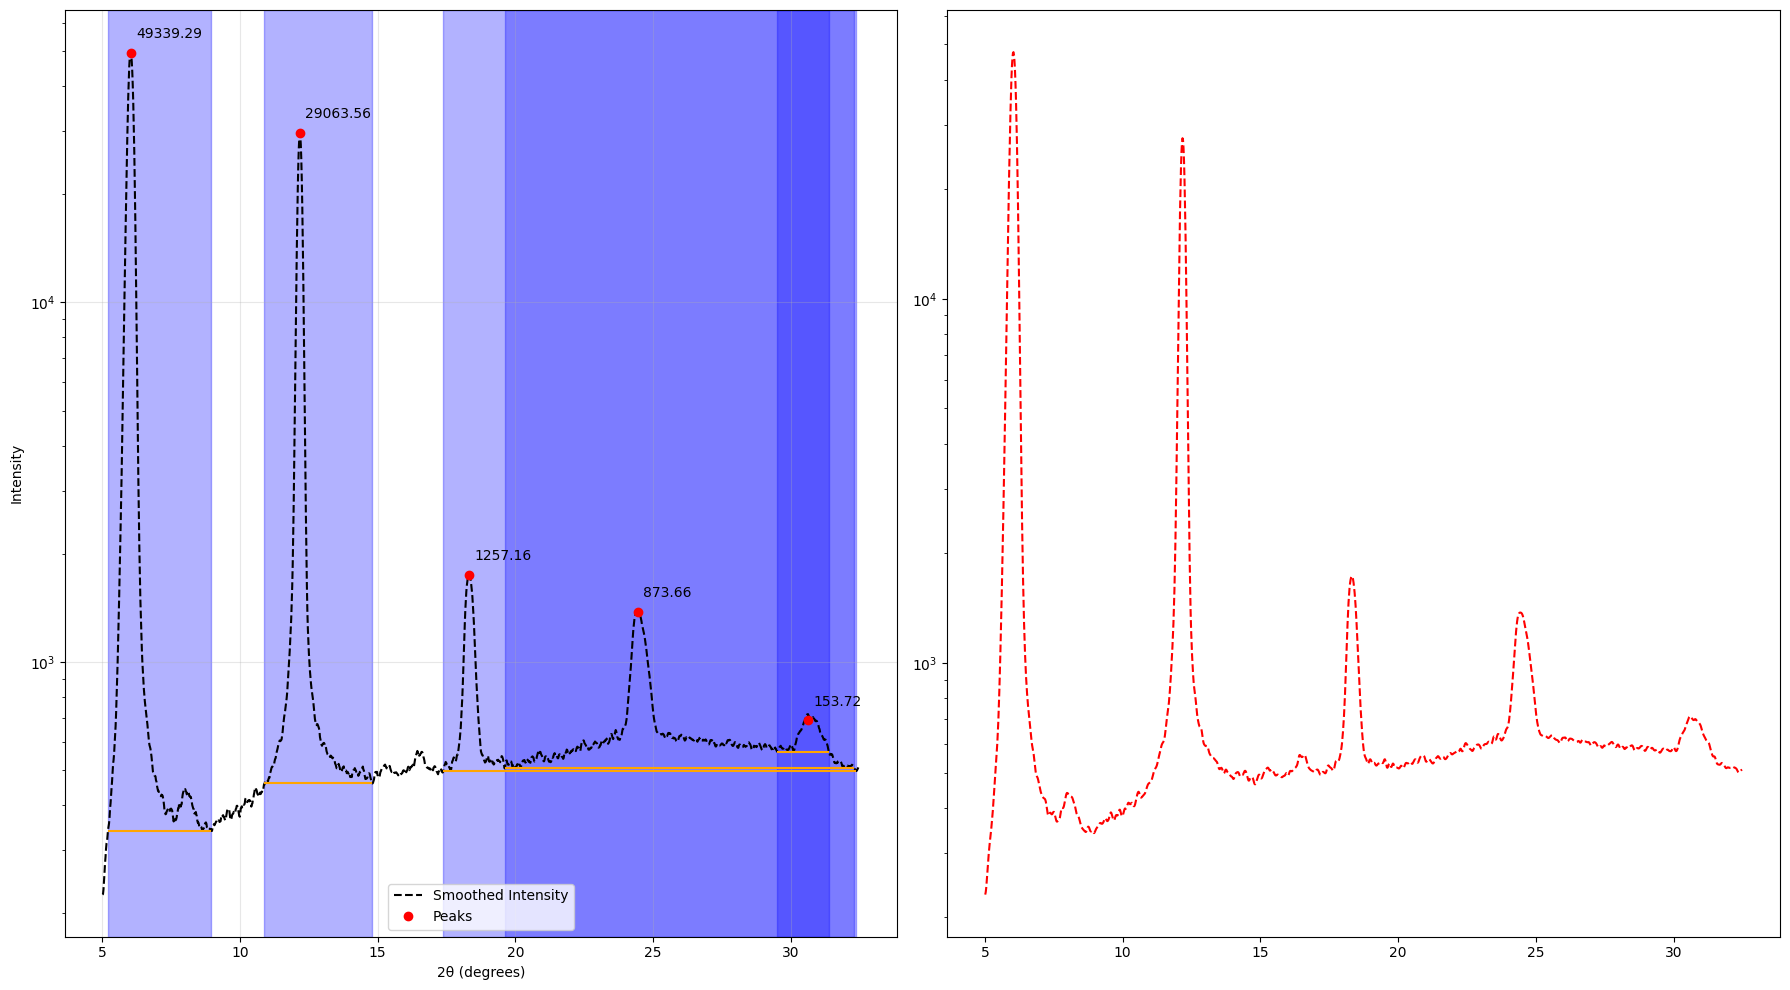

In [63]:
from gadds import AreaDetectorImage
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from scipy.ndimage import gaussian_filter

from package.analysis_utils import find_peaks_and_widths


# Load and convert data
gfrm_file = r"test\20250709_S_MeO_B01_000.gfrm"
area_detector = AreaDetectorImage(gfrm_file)
# Compare the three methods
methods = ['normalize']

prominence = 100
height = None
distance = 5

fig, (ax, ax2) = plt.subplots(1, 2, figsize=(18, 10))
for i, method in enumerate(methods):
    area_detector.convert(overlap_method=method)
    (twoth_values, intensity), _ = area_detector.integrate_2theta()

    # Do gaussian smoothing before peak finding
    smoothed_intensity = savgol_filter(intensity, window_length=11, polyorder=3)
    gaussian_smoothed_intensity = gaussian_filter(intensity, sigma=2)

    peaks, widths, width_heights, left_ips, right_ips, prominences = find_peaks_and_widths(twoth_values, intensity, width_at_height=1)

    # (ax1).plot(twoth_values, intensity, label=f"Method: '{method}'")
    ax.plot(twoth_values, smoothed_intensity, 'k--', label='Smoothed Intensity')
    ax2.plot(twoth_values, gaussian_smoothed_intensity, 'r--', label='Gaussian Smoothed Intensity')
    ax.plot(*peaks, 'ro', label='Peaks')
    ax.hlines(width_heights, left_ips, right_ips, color='orange')
    for prominence, peak in zip(prominences, zip(*peaks)):
        ax.text(peak[0] + 0.2, peak[1] * 1.1, f'{prominence:.2f}')

    for left_ip, right_ip in zip(left_ips, right_ips):
        ax.axvspan(left_ip, right_ip, color='blue', alpha=0.3)

ax.set_xlabel('2θ (degrees)')
ax.set_ylabel('Intensity')
ax.set_yscale('log')
ax2.set_yscale('log')
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()



In [22]:
from gadds import AreaDetectorImage

gfrm_files = [r"test\20250709_S_MeO_B01_000.gfrm", r"test\20250709_S_MeO_B01_001.gfrm", r"G:\My Drive\LPS\20250819_S_MeOMBAI_prestudy_4\XRD\20250822_S_MeO_1\S_MeO_pre4_1_A01_000.gfrm"]

area_detectors = []
area_detectors_summed = []

for gfrm_file in gfrm_files:
    area_detector = AreaDetectorImage(gfrm_file)
    area_detector.convert()
    area_detectors.append(area_detector)
    area_detector = AreaDetectorImage(gfrm_file)
    area_detector.convert(overlap_method='sum')
    area_detectors_summed.append(area_detector)

Info: 1281901 grid points have overlapping detector pixels (max 6 pixels per grid point)
Info: 1374788 grid points have overlapping detector pixels (max 6 pixels per grid point)
Info: 1281901 grid points have overlapping detector pixels (max 6 pixels per grid point)


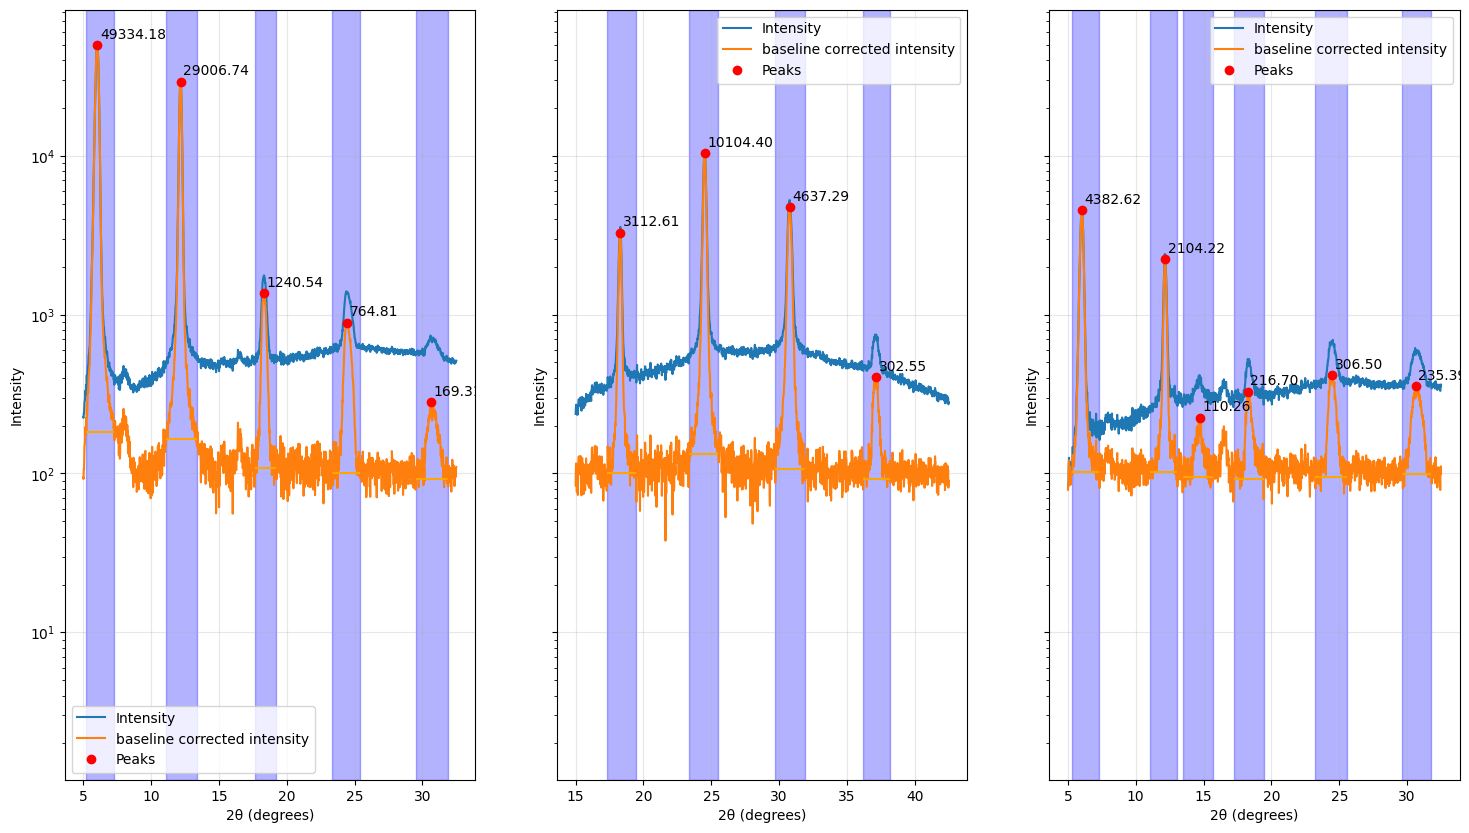

In [23]:
import matplotlib.pyplot as plt

from package.analysis_utils import find_peaks_and_widths, correct_baseline

fig, axes = plt.subplots(1, len(gfrm_files), figsize=(18, 10), sharey=True)

for ax, area_detector in zip(axes, area_detectors):
    (twoth_values, intensity), *_ = area_detector.integrate_2theta()
    # Correct baseline
    corrected_intensity, _ = correct_baseline(twoth_values, intensity, offset=100)
    peaks, peaks_property = find_peaks_and_widths(twoth_values, corrected_intensity, width_at_height=1, wlen=2.5)
    ax.plot(twoth_values, intensity, label='Intensity')
    ax.plot(twoth_values, corrected_intensity, label='baseline corrected intensity')

    ax.plot(*zip(*peaks), 'ro', label='Peaks')
    for peak, props in zip(peaks, peaks_property):
        ax.text(peak[0] + 0.2, peak[1] * 1.1, f'{props["prominence"]:.2f}', clip_on=True)
        ax.hlines(props['width_height'], props['left_ip'], props['right_ip'], color='orange')
        ax.axvspan(props['left_ip'], props['right_ip'], color='blue', alpha=0.3)
    
    # for left_ip, right_ip, peak, width in zip(left_ips, right_ips, zip(*peaks), widths):
    #     ax.axvspan(peak[0] - (width / 2) * 1.5, peak[0] + (width / 2) * 1.5, color='orange', alpha=0.3)

    ax.set_xlabel('2θ (degrees)')
    ax.set_ylabel('Intensity')
    ax.set_yscale('log')
    ax.grid(True, alpha=0.3)
    ax.legend()



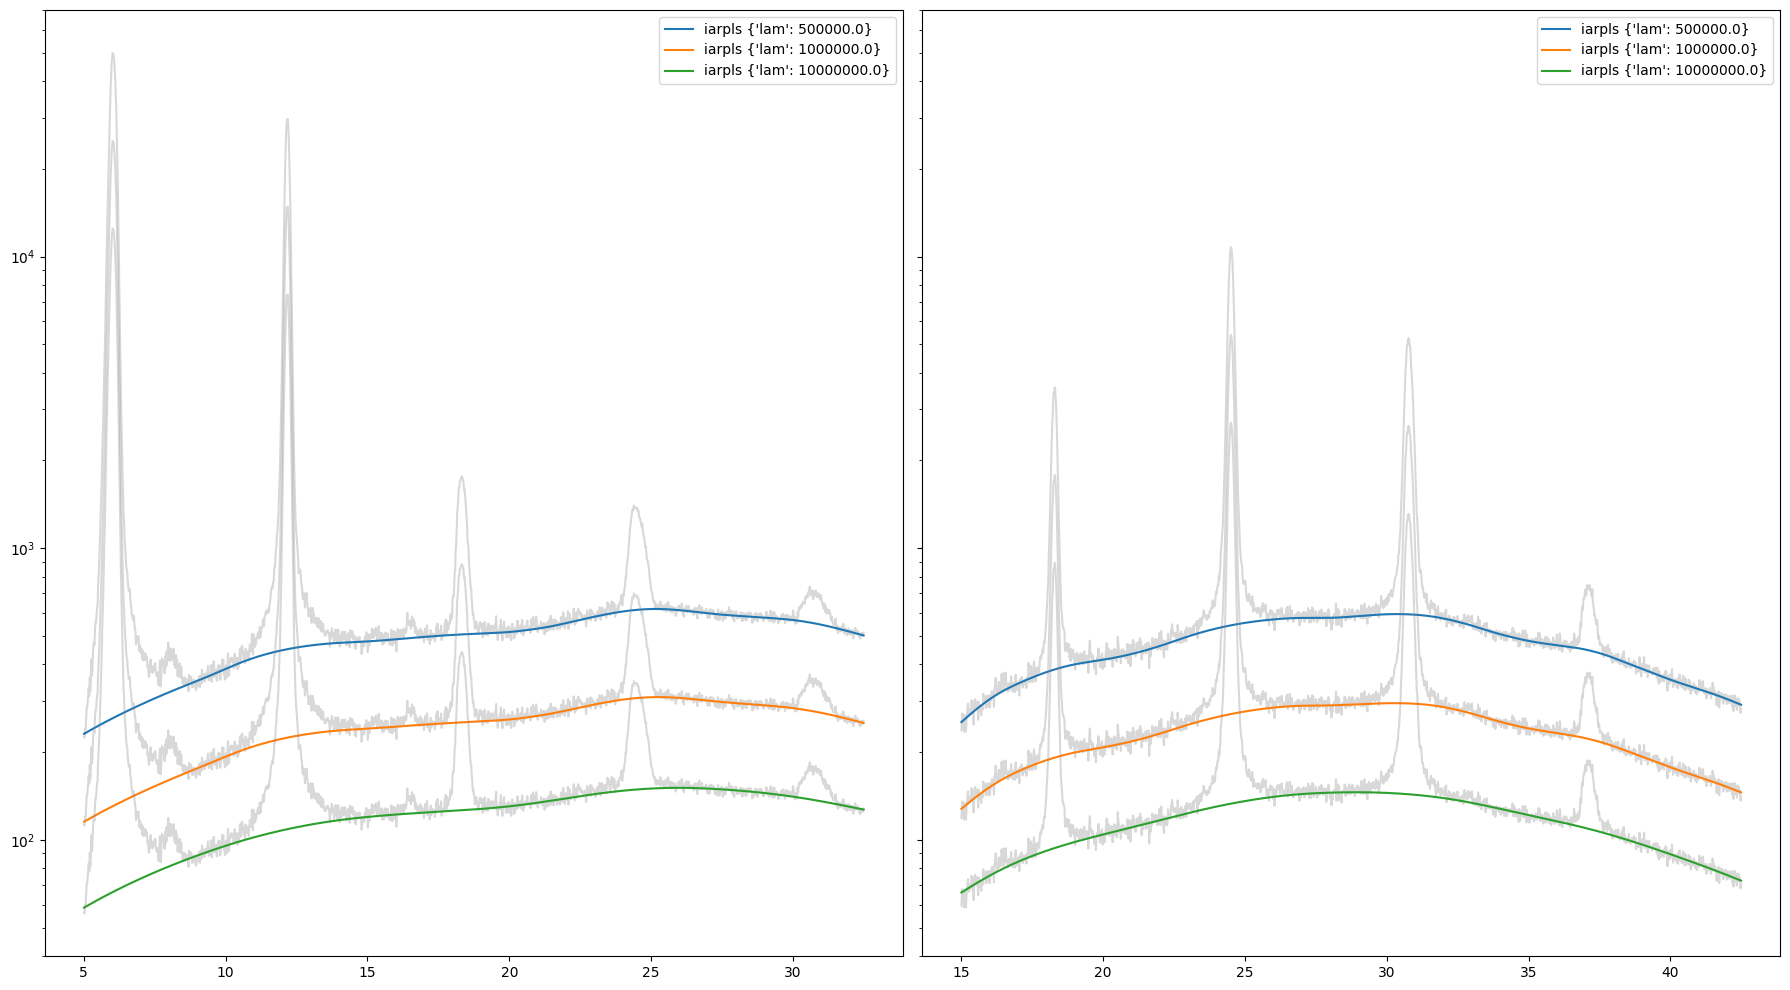

In [10]:
import matplotlib.pyplot as plt

from pybaselines import Baseline, utils

pad_len = 0
extrapolate_window = (5, 20)
methods = (
    # ('penalized_poly', {'poly_order': 4}),
    # ('mixture_model', {'lam': 1e6}),
    ('iarpls', {'lam': 5e5}),
    ('iarpls', {'lam': 1e6}),
    ('iarpls', {'lam': 1e7}),
    # ('mor', {'half_window': 50}),
    # ('ria', {'half_window': 50}),
    # ('std_distribution', {'half_window': 25})
)

# Load and convert data

fig, axes = plt.subplots(1, len(gfrm_files), figsize=(18, 10), sharey=True)

for ax, area_detector in zip(axes, area_detectors):

    (twoth_values, intensity), _ = area_detector.integrate_2theta()

    x = twoth_values
    y = intensity

    if pad_len > 0:
        y = utils.pad_edges(y, pad_len, extrapolate_window=extrapolate_window)
        x_spacing = x[1] - x[0]
        x = np.linspace(x[0] - x_spacing * pad_len, x[-1] + x_spacing * pad_len, len(y))

    # ax.plot(x, y)
    for i, (method, kwargs) in enumerate(methods):
        baseline_fitter = Baseline(x_data=x, check_finite=False, assume_sorted=True)
        func = getattr(Baseline(x, check_finite=False, assume_sorted=True), method)
        calc_baseline = func(y, **kwargs)[0]
        ax.plot(x, y * (0.5 ** i), alpha=0.3, color='gray')
        ax.plot(x, calc_baseline * (0.5 ** i), label=f'{method} {kwargs}')

    ax.legend()
    ax.set_yscale('log')
    # ax.set_ylim(50, 1000)

plt.tight_layout()
plt.show()

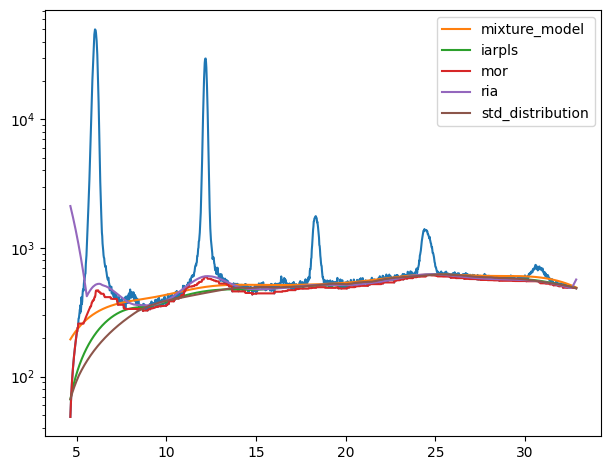

In [64]:
import matplotlib.pyplot as plt
import numpy as np
from pybaselines import Baseline, utils

x = twoth_values
y = intensity
pad_len = 20
extrapolate_window = (5, 20)

y = utils.pad_edges(y, pad_len, extrapolate_window=extrapolate_window)

x_spacing = x[1] - x[0]

x = np.linspace(x[0] - x_spacing * pad_len, x[-1] + x_spacing * pad_len, len(y))

# baseline_fitter = Baseline(x_data=x)

# bkg_1, params_1 = baseline_fitter.modpoly(y, poly_order=3)
# bkg_2, params_2 = baseline_fitter.asls(y, lam=1e7)
# bkg_3, params_3 = baseline_fitter.mor(y)
# bkg_4, params_4 = baseline_fitter.snip(
#     y, max_half_window=40, decreasing=True, smooth_half_window=3
# )

# plt.plot(x, y, label='raw data', lw=1.5)
# # plt.plot(x, bkg_1, '--', label='modpoly')
# plt.plot(x, bkg_2, '--', label='asls')
# plt.plot(x, bkg_3, '--', label='mor')
# plt.plot(x, bkg_4, '--', label='snip')

# plt.yscale('log')
# plt.legend()
# plt.show()

methods = (
    # ('penalized_poly', {'poly_order': 4}),
    ('mixture_model', {'lam': 1e5}),
    ('iarpls', {'lam': 1e5}),
    ('mor', {'half_window': 40}),
    ('ria', {'half_window': 50}),
    ('std_distribution', {'half_window': 25})
)
plt.plot(x, y)
for method, kwargs in methods:
    baseline_fitter = Baseline(x_data=x, check_finite=False, assume_sorted=True)
    func = getattr(Baseline(x, check_finite=False, assume_sorted=True), method)
    calc_baseline = func(y, **kwargs)[0]
    plt.plot(x, calc_baseline, label=method)
    
plt.legend()
plt.tight_layout()
plt.yscale('log')

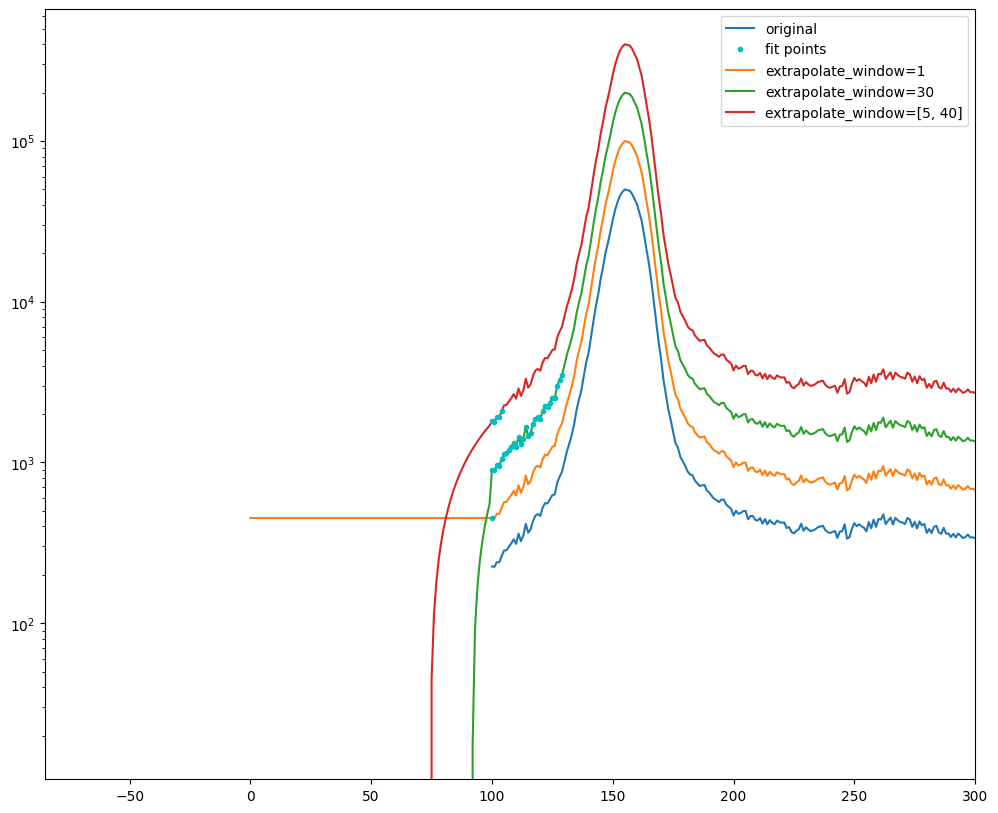

In [39]:
import matplotlib.pyplot as plt
import numpy as np

from pybaselines.utils import _check_scalar, gaussian, pad_edges


pad_len = 100

x = twoth_values
y = intensity

_, ax = plt.subplots(1,1, figsize=(12, 10))

patch = ax.plot(pad_edges(y, pad_len, mode='constant', constant_values=np.nan))[0]
extrapolate_windows = (1, 30, [5, 40])
legend = [[patch], ['original']]
for i, extrapolate_window in enumerate(extrapolate_windows, 1):
    padded_y = pad_edges(y, pad_len, extrapolate_window=extrapolate_window)
    # offset each plot to show differences
    padded_y *= 2 ** i
    patch = ax.plot(padded_y)[0]
    legend[0].append(patch)
    legend[1].append(f'extrapolate_window={extrapolate_window}')

    # show only the section used for extrapolation
    padded_y[:pad_len] = np.nan
    padded_y[-pad_len:] = np.nan
    windows = _check_scalar(extrapolate_window, 2, True)[0]
    padded_y[pad_len + windows[0]:-pad_len - windows[1]] = np.nan
    section_patch = ax.plot(padded_y, 'c.')[0]

# ax.set_ylim([None, 31])
legend[0].insert(1, section_patch)
legend[1].insert(1, 'fit points')
ax.set_xlim(None, pad_len + 200)
ax.legend(*legend)
ax.set_yscale('log')
plt.show()

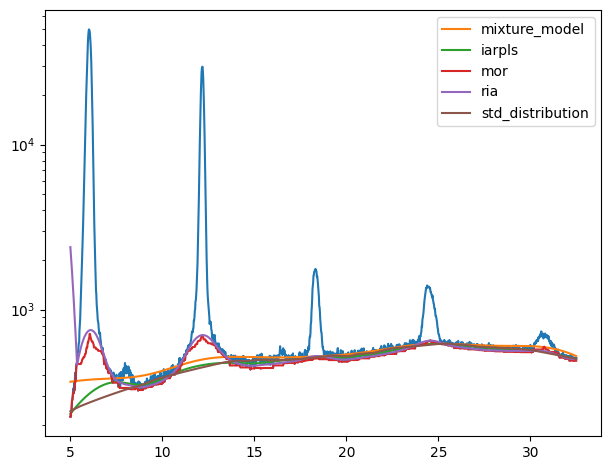

In [49]:


methods = (
    # ('penalized_poly', {'poly_order': 4}),
    ('mixture_model', {'lam': 1e5}),
    ('iarpls', {'lam': 1e5}),
    ('mor', {'half_window': 30}),
    ('ria', {'half_window': 20}),
    ('std_distribution', {'half_window': 25})
)
plt.plot(x, y)
for method, kwargs in methods:
    baseline_fitter = Baseline(x_data=x, check_finite=False, assume_sorted=True)
    func = getattr(Baseline(x, check_finite=False, assume_sorted=True), method)
    calc_baseline = func(y, **kwargs)[0]
    plt.plot(x, calc_baseline, label=method)
    
plt.legend()
plt.tight_layout()
plt.yscale('log')


In [5]:
from gadds import AreaDetectorImage
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from pathlib import Path

from package.analysis_utils import correct_baseline, find_peaks_and_widths
import pandas as pd

gfrm_files = [
    *list(Path(r"G:\My Drive\LPS\20250904_LPS_pre_5\XRD").glob("**/*_000.gfrm")),
]

for gfrm_file in gfrm_files:
    print(f"Processing {gfrm_file}...")

    save_path = str(Path(gfrm_file).with_suffix(''))[:-4]

    area_detector = AreaDetectorImage(gfrm_file)
    area_detector.convert()
    (twoth_values, intensity), *_ = area_detector.integrate_2theta()


    # Save the 2θ integration data as CSV
    # df_2theta = pd.DataFrame({
    #     'twoth_degrees': twoth_values,
    #     'intensity': intensity
    # })
    # csv_filename = save_path + '_merge.xy'
    # df_2theta.to_csv(csv_filename, index=False, sep='\t', header=False)
    # print(f"Saved 2θ integration data to {csv_filename}")

    corrected_intensity, _ = correct_baseline(twoth_values, intensity, offset=100)    

    peaks, peaks_prop = find_peaks_and_widths(twoth_values, corrected_intensity, width_at_height=1, wlen=2.5)
    twoth_ranges = [
        (prop['left_ip'], prop['right_ip']) for prop in peaks_prop
    ]
    print(f"Found {len(twoth_ranges)} peaks: {twoth_ranges}")
    # twotheta_csv_filename = save_path + f'_gamma_{int(np.mean(twoth_range))}.xy'
    # df_twotheta = pd.DataFrame({
    #         'gamma_degrees': twoth_values,
    #         'intensity': intensity
    #     })
    # df_twotheta.to_csv(twotheta_csv_filename, index=False, sep='\t', header=False)

    # only keep the one around 10.5
    twoth_ranges = [r for r in twoth_ranges if 10 < np.mean(r) < 15]

    for i, twoth_range in enumerate(twoth_ranges):
        # if i > 0: # Limit to first two peaks for brevity
        #     break

        intensity, (twoth_range, gamma_range), mask = area_detector.integrate_gamma(twotheta_range=twoth_range)

        # Save the γ integration data for this peak
        df_gamma = pd.DataFrame({
            'gamma_degrees': intensity[0],
            'intensity': intensity[1]
        })
        gamma_csv_filename = save_path + f'_gamma_{int(np.mean(twoth_range))}.xy'
        df_gamma.to_csv(gamma_csv_filename, index=False, sep='\t', header=False)
        print(f"Saved γ integration data for peak {i+1} to {gamma_csv_filename}")

        corrected_intensity, _ = correct_baseline(intensity[0], intensity[1], offset=100)
        df_gamma = pd.DataFrame({
            'gamma_degrees': intensity[0],
            'corrected_intensity': corrected_intensity
        })
        gamma_csv_filename = save_path + f'_gamma_{int(np.mean(twoth_range))}_corrected.xy'
        df_gamma.to_csv(gamma_csv_filename, index=False, sep='\t', header=False)

    



Processing G:\My Drive\LPS\20250904_LPS_pre_5\XRD\20250905_LPS_pre5_1\LPS_pre5_1_A01_000.gfrm...
Info: 1281901 grid points have overlapping detector pixels (max 6 pixels per grid point)
Found 6 peaks: [(np.float64(5.193125356521529), np.float64(7.245034604577118)), (np.float64(10.92747888010545), np.float64(13.364121112171462)), (np.float64(13.400762348743882), np.float64(15.745801489378842)), (np.float64(17.21145095227569), np.float64(19.59313132948307)), (np.float64(23.825194153597725), np.float64(25.21756114334973)), (np.float64(29.4862652040368), np.float64(31.77634248981313))]
Saved γ integration data for peak 1 to G:\My Drive\LPS\20250904_LPS_pre_5\XRD\20250905_LPS_pre5_1\LPS_pre5_1_A01_gamma_12.xy
Saved γ integration data for peak 2 to G:\My Drive\LPS\20250904_LPS_pre_5\XRD\20250905_LPS_pre5_1\LPS_pre5_1_A01_gamma_14.xy
Processing G:\My Drive\LPS\20250904_LPS_pre_5\XRD\20250905_LPS_pre5_1\LPS_pre5_1_A02_000.gfrm...
Info: 1281901 grid points have overlapping detector pixels (max 

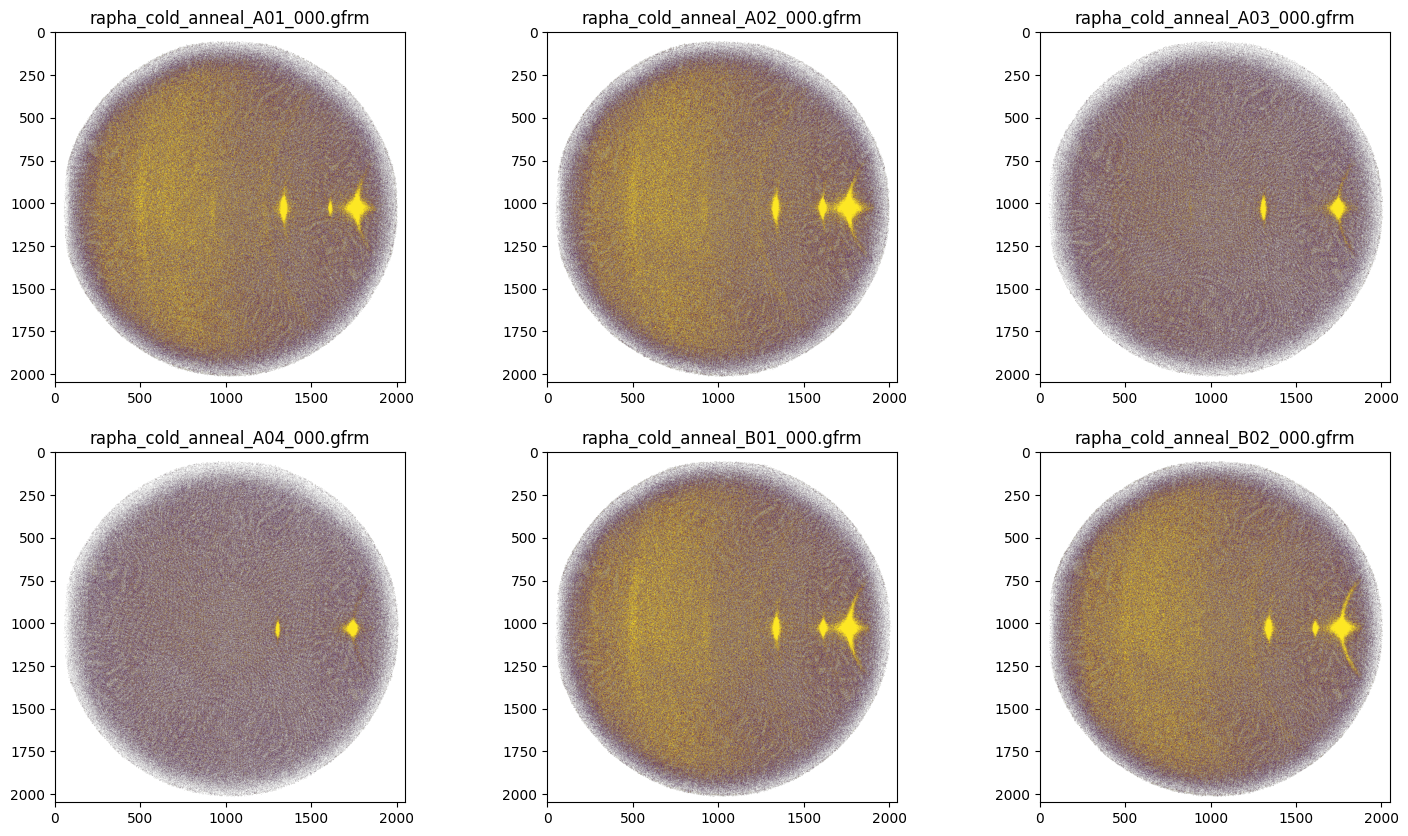

In [37]:
from gadds import AreaDetectorImage
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from pathlib import Path

from package.analysis_utils import correct_baseline, find_peaks_and_widths
import pandas as pd

gfrm_files = [
    *list(Path(r"D:\XRD\20250902_rapha_cold").glob("*_000.gfrm")),
]

fig, axes = plt.subplots(2, len(gfrm_files)//2, figsize=(18, 10))

axes = axes.flatten()

for i, gfrm_file in enumerate(gfrm_files):

    save_path = str(Path(gfrm_file).with_suffix(''))[:-4]

    area_detector = AreaDetectorImage(gfrm_file)

    im1 = axes[i].imshow(area_detector.image.data, 
                #  cmap=(mpl.cm.viridis).with_extremes(under='black'),
                 cmap='viridis',
                 norm=colors.LogNorm(vmin=1, vmax=np.percentile(area_detector.image.data, 92)),
                 origin='upper')
    
    axes[i].set_title(Path(gfrm_file).name)
    # area_detector.convert()

    # (twoth_values, intensity), *_ = area_detector.integrate_2theta()


    # # Save the 2θ integration data as CSV
    # # df_2theta = pd.DataFrame({
    # #     'twoth_degrees': twoth_values,
    # #     'intensity': intensity
    # # })
    # # csv_filename = save_path + '_merge.xy'
    # # df_2theta.to_csv(csv_filename, index=False, sep='\t', header=False)
    # # print(f"Saved 2θ integration data to {csv_filename}")

    # corrected_intensity, _ = correct_baseline(twoth_values, intensity, offset=100)    

    # peaks, peaks_prop = find_peaks_and_widths(twoth_values, corrected_intensity, width_at_height=1, wlen=2.5)
    # twoth_ranges = [
    #     (prop['left_ip'], prop['right_ip']) for prop in peaks_prop
    # ]
    # twotheta_csv_filename = save_path + f'_gamma_{int(np.mean(twoth_range))}.xy'
    # df_twotheta = pd.DataFrame({
    #         'gamma_degrees': twoth_values,
    #         'intensity': intensity
    #     })
    # df_twotheta.to_csv(twotheta_csv_filename, index=False, sep='\t', header=False)

    # # only keep the one around 10.5
    # twoth_ranges = [r for r in twoth_ranges if 10 < np.mean(r) < 15]

    # for i, twoth_range in enumerate(twoth_ranges):
    #     # if i > 0: # Limit to first two peaks for brevity
    #     #     break

    #     intensity, (twoth_range, gamma_range), mask = area_detector.integrate_gamma(twotheta_range=twoth_range)

    #     # Save the γ integration data for this peak
    #     df_gamma = pd.DataFrame({
    #         'gamma_degrees': intensity[0],
    #         'intensity': intensity[1]
    #     })
    #     gamma_csv_filename = save_path + f'_gamma_{int(np.mean(twoth_range))}.xy'
    #     df_gamma.to_csv(gamma_csv_filename, index=False, sep='\t', header=False)
    #     print(f"Saved γ integration data for peak {i+1} to {gamma_csv_filename}")

    #     corrected_intensity, _ = correct_baseline(intensity[0], intensity[1], offset=100)
    #     df_gamma = pd.DataFrame({
    #         'gamma_degrees': intensity[0],
    #         'corrected_intensity': corrected_intensity
    #     })
    #     gamma_csv_filename = save_path + f'_gamma_{int(np.mean(twoth_range))}_corrected.xy'
    #     df_gamma.to_csv(gamma_csv_filename, index=False, sep='\t', header=False)

    



- age drawer overnight in the dark, measure XRD
Redo experiments
- cold annealing or 100C
- in DMF
- S-MBAI, 1 step 2:1 precursor mixture (0.2M/0.1M) or single crystal (0.1M)
- S-p-MeOMBAI 2:1 solvent mixture (0.2M/0.1M)